In [1]:
import numpy as np

from radioimaging.util import util
import matplotlib.pyplot as plt
import matplotlib
from scipy.signal.windows import kaiser

cmap="turbo"
plt.set_loglevel("critical")

## Definition of operators

In [2]:
def generate_measurement_operator(img, baseline_dependent_effects=True, sample_prob=0.5, mask=None, beta=10, bde_mul=0.1):
    dim1d = img.shape[0]
    dim = img.shape[0] * img.shape[1]
    half_operator = np.zeros((dim, dim), dtype=complex)
    bde = 1
    rng = np.random.default_rng()
    mid = dim//2

    image1d = kaiser(dim1d, beta)
    image2d = np.zeros(img.shape)
    
    for y in range(dim1d):
        for x in range(dim1d):
            image2d[x, y] = image1d[x] * image1d[y]
    
    kernel2d = np.fft.ifftshift(np.fft.fft2(np.fft.fftshift(image2d)))
    
    for y in range(dim1d):
        for x in range(dim1d):
            row_idx = y * dim1d + x
            
            if (mask is not None and mask[row_idx] == True) or (mask is None and rng.random() < sample_prob):
                curr_bde = bde if not baseline_dependent_effects else bde + (rng.random() - 0.5)*bde_mul
                #this should technically be closer to a shift than a multiplication to mirror the w effect
                rolled_kernel = np.roll(kernel2d, shift=(y - mid, x-mid), axis=(0,1))
                #util.plotNImages([rolled_kernel], [""], cmap=cmap)
                half_operator[row_idx,:] = rolled_kernel.reshape(dim1d * dim1d) * curr_bde

    operator = half_operator @ half_operator.conj().T

    return operator, half_operator

def generate_mask(img, beta):
    dist = kaiser(img.shape[0], beta)
    rng = np.random.default_rng()
    norm = np.max(dist) ** 2

    mask = np.zeros(img.shape, dtype=int)

    for i in range(img.shape[0]):
        for j in range(i+1):
            if rng.random() < dist[i] * dist[j] / norm:
                mask[i,j] = mask[j,i] = 1
    
    return mask
    

In [3]:
def tikh(resid, gamma, regparam, with_operator=False):
    diag = np.diag(gamma)
    reg = regparam * np.ones(diag.shape)
    tikh = diag / (diag * diag + reg)

    if not with_operator:
        return resid * tikh
    else:
        return np.diag(tikh)

In [4]:
#finds a regularization parameter lambda so that M Gamma has lambda_max < n
#for more efficiency ideally want to use a truncated eigendecomp method or just implement a separate power iteration function
def find_lambda(gamma, n=1):
    diag = np.diag(gamma)
    vals, vecs = np.linalg.eig(operator)

    rhogamma = vals[0]
    dmin = np.min(diag)
    dmax = np.max(diag)

    return (dmax * (rhogamma/n - dmin)).real

## Precalc mask so we always get the same one (mainly for comparison purposes)

In [5]:
xcenter = 280
ycenter = 283
hw = 16
sky = util.fromfits("../data/SGRB_full_gt.fits")[ycenter-hw:ycenter+hw, xcenter-hw:xcenter+hw]
vtrue = np.fft.fft2(sky)

mask = np.fft.fftshift(generate_mask(vtrue, 6))

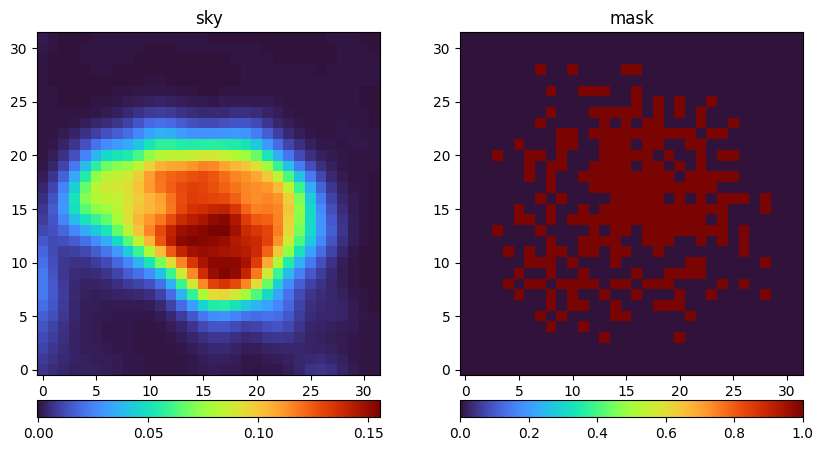

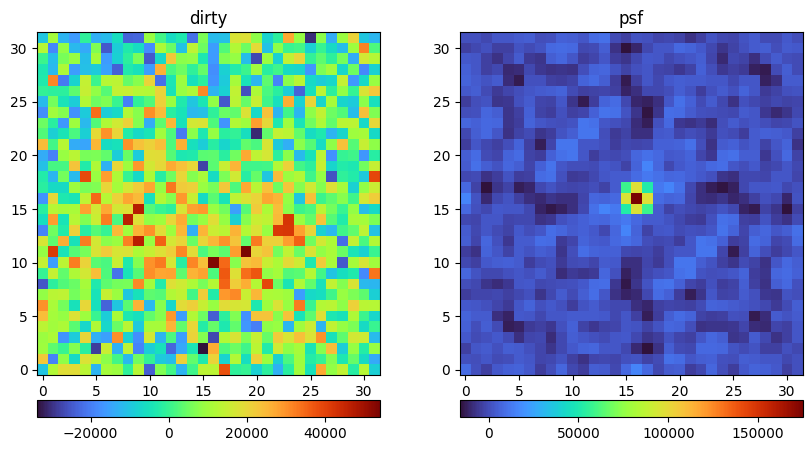

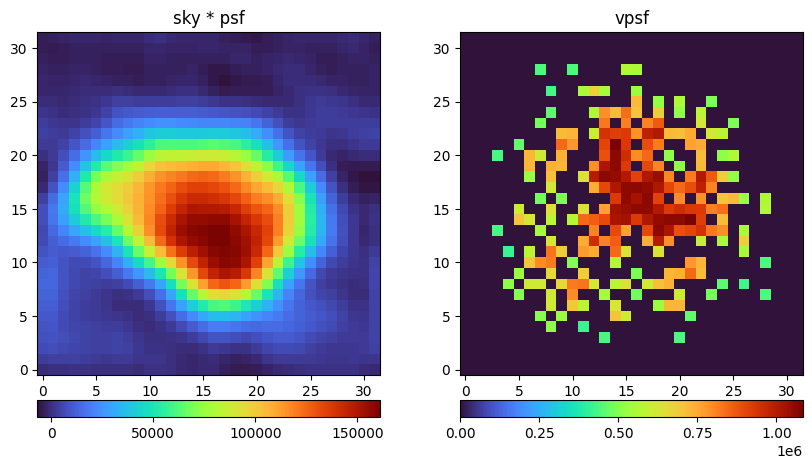

In [6]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

ones = np.ones(vtrue.shape)

operator, half_operator = generate_measurement_operator(vtrue, baseline_dependent_effects=True, beta=2, sample_prob=1, mask=mask.reshape(mask.shape[0]*mask.shape[1]), bde_mul=0)
#operator, half_operator = generate_measurement_operator(vtrue, baseline_dependent_effects=True, beta=2, sample_prob=1, bde_mul=0)

noise_level = 0.1
vgop = (operator @ vtrue.reshape(vtrue.shape[0]*vtrue.shape[1])).reshape(vtrue.shape)
sigma = np.max(np.abs(vgop)) * noise_level
vnoise = (np.random.normal(scale=sigma, size=sky.shape) + 1j*np.random.normal(scale=sigma, size=sky.shape)) / np.sqrt(2)
vgop += vnoise
vpsf = (operator @ ones.reshape(ones.shape[0]*ones.shape[1])).reshape(ones.shape)
dirty = np.fft.ifft2(vgop).real
psf = np.fft.ifftshift(np.fft.ifft2(vpsf)).real

util.plotNImages([sky, np.fft.fftshift(mask)],["sky", "mask"],cmap=cmap)
util.plotNImages([dirty, psf],["dirty", "psf"],cmap=cmap)

conv = util.convolve2d(sky, psf)
util.plotNImages([conv, np.fft.fftshift(np.abs(vpsf))], ["sky * psf", "vpsf"], cmap=cmap)

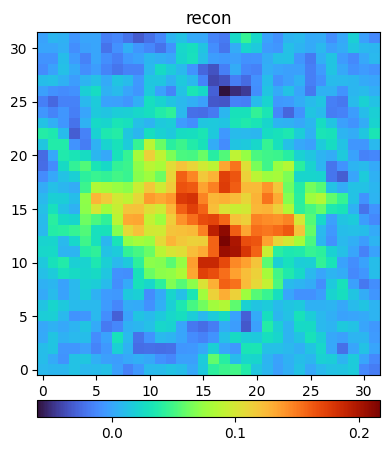

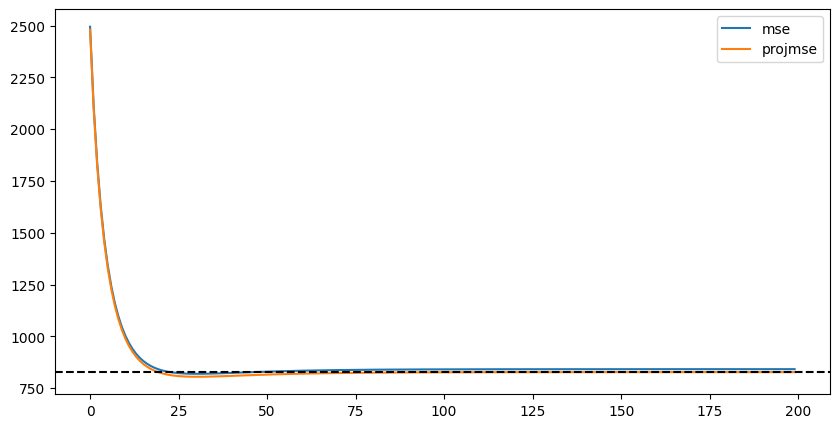

In [9]:
matplotlib.rcParams['figure.figsize'] = [10, 5]
nmajcyc = 200

vrecon = np.zeros(vgop.shape, dtype=complex)
vresid = vgop
regparam = find_lambda(operator)
mses = np.zeros((nmajcyc,))
projmses = np.zeros((nmajcyc,))
maskreshape = mask.reshape(vresid.shape[0]*vresid.shape[1])

m = tikh(vresid.reshape(vresid.shape[0]*vresid.shape[1]), operator, regparam, with_operator=True)
mgamma = m @ operator
vals, vecs = np.linalg.eig(mgamma)
valspi = [0 if np.abs(x) == 0 else 1/x for x in vals]
mgammapi = vecs @ np.diag(valspi) @ np.linalg.inv(vecs)
lim = -mgammapi @ m @ vnoise.reshape(vresid.shape[0]*vresid.shape[1])

for i in range(nmajcyc):
    #vdeconv = tikh(vresid.reshape(vresid.shape[0]*vresid.shape[1]), operator, regparam).reshape(vresid.shape[0], vresid.shape[1])
    vdeconv = (m @ vresid.reshape(vresid.shape[0]*vresid.shape[1])).reshape(vresid.shape[0], vresid.shape[1])
    vrecon += vdeconv
    vresid = vgop - (operator @ vrecon.reshape(vresid.shape[0]*vresid.shape[1])).reshape(vresid.shape)
    mses[i] = np.linalg.norm(vtrue - vrecon)**2
    projmses[i] = np.linalg.norm(mgamma @ mgammapi @ (vtrue - vrecon).reshape(vresid.shape[0]*vresid.shape[1]))**2
    #util.plotNImages([np.fft.ifft2(vrecon).real], ["recon"], cmap=cmap)

recon = np.fft.ifft2(vrecon).real
util.plotNImages([recon], ["recon"], cmap=cmap)
#print(mses[250:])
plt.plot(mses, label="mse")
plt.plot(projmses, label="projmse")
plt.axhline(y=np.linalg.norm(lim)**2, linestyle="--", c="black")
plt.legend(loc="upper right")
plt.show()

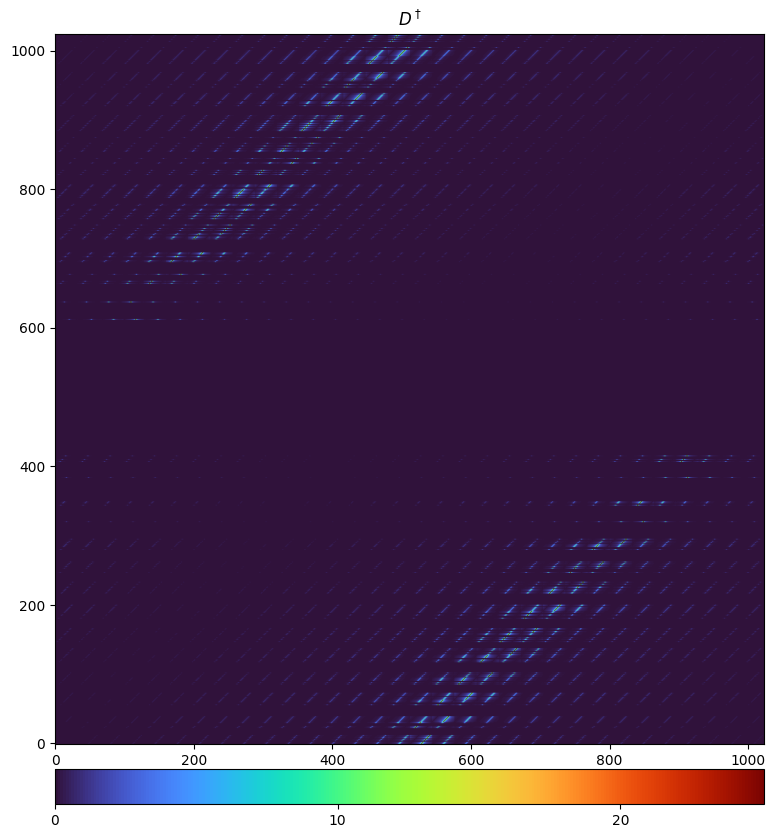

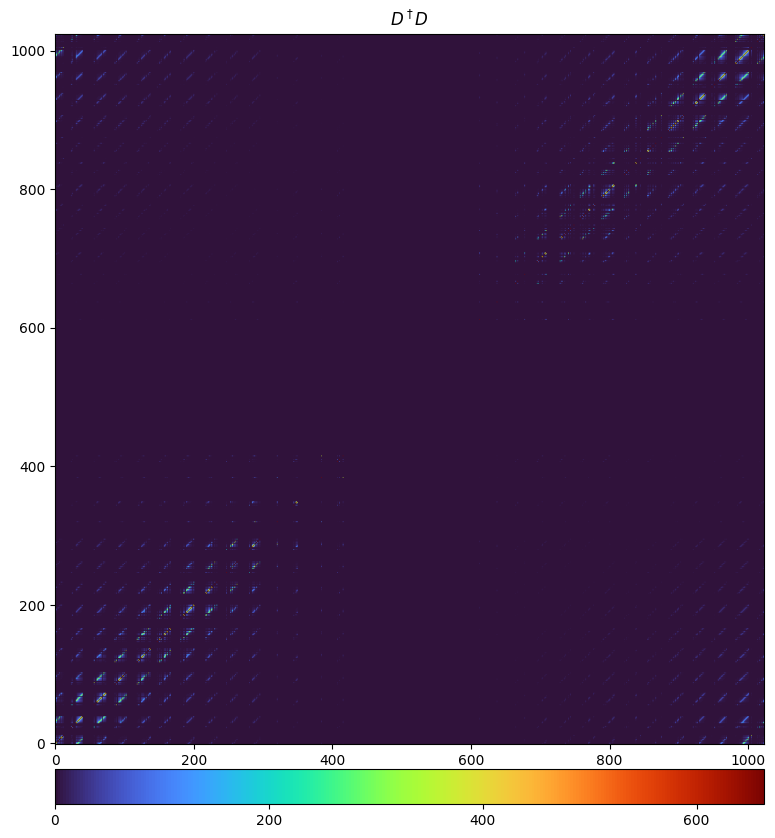

NameError: name 'm' is not defined

In [7]:
matplotlib.rcParams['figure.figsize'] = [10, 10]

util.plotNImages([np.abs(half_operator)**0.5], ["$D^\dagger$"], cmap=cmap)
util.plotNImages([np.abs(operator)**0.5], ["$D^\dagger D$"], cmap=cmap)
util.plotNImages([np.abs(m)], ["$M$"], cmap=cmap)

In [9]:
initlmbd = regparam * 0.05
vals, vecs = np.linalg.eig(operator)
delta = np.diag(operator)
lmbdmaxgamma = vals[0]

rowinf = []
lmax = []
rquot = []
frob = []
lmbds = []

for i in range(1, 100):      
    currlmbd = initlmbd * i
    m = tikh(vresid.reshape(vresid.shape[0]*vresid.shape[1]), operator, currlmbd, with_operator=True)
    mgamma = m @ operator

    rowinf.append(np.linalg.norm(np.eye(mgamma.shape[0]) - mgamma, ord=np.inf))
    rquot.append(lmbdmaxgamma / (np.min(delta) + currlmbd/np.max(delta)))
    frob.append(np.linalg.norm(np.eye(mgamma.shape[0]) - mgamma, ord='fro'))

    vals, vecs = np.linalg.eig(np.eye(mgamma.shape[0]) - mgamma)
    lmax.append(vals[0])

    lmbds.append(currlmbd)

/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


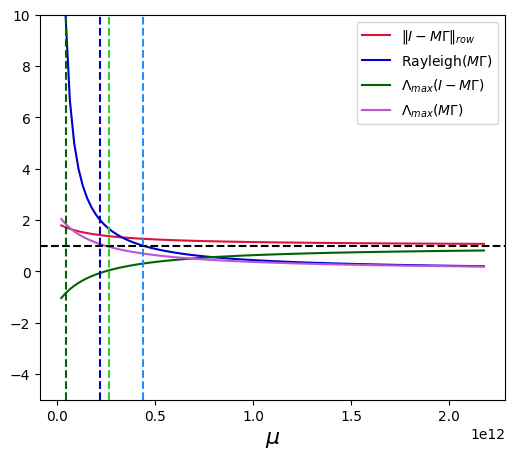

In [10]:
lmbdmgamma = [1 - x for x in lmax]

realp1 = 0
realp2 = 0
prev = 9999
for i, lmbd in enumerate(lmbdmgamma):
    if prev >= 1 and lmbd < 1:
        realp1 = lmbds[i]
    if prev >= 2 and lmbd < 2:
        realp2 = lmbds[i]

    prev = lmbd

matplotlib.rcParams['figure.figsize'] = [6, 5]
plt.plot(lmbds, rowinf, label="$\| I - M \Gamma \|_{row}$", c="crimson")
plt.plot(lmbds, rquot, label="Rayleigh($M \Gamma$)", c="mediumblue")
#plt.plot(lmbds, frob, label="Frobenius")
plt.plot(lmbds, lmax, label="$\Lambda_{max}(I - M \Gamma)$", c="darkgreen")
plt.plot(lmbds, [1 - x for x in lmax], label="$\Lambda_{max}(M \Gamma)$", c="mediumorchid")

plt.axhline(y=1, linestyle="--", c="black")

rparam1 = find_lambda(operator, n=1)
rparam2 = find_lambda(operator, n=2)

plt.axvline(x=rparam1, linestyle="--", c="dodgerblue")
plt.axvline(x=rparam2, linestyle="--", c="mediumblue")

plt.axvline(x=realp1, linestyle="--", c="limegreen")
plt.axvline(x=realp2, linestyle="--", c="darkgreen")

plt.xlabel(r"$\mu$", fontsize=16)

plt.legend(loc="upper right")

#plt.xlim(0, 1e12)
plt.ylim(-5, 10)

plt.savefig("../figures/convergence_conditions.png", pad_inches=0.0, bbox_inches='tight')

In [10]:
m = tikh(vresid.reshape(vresid.shape[0]*vresid.shape[1]), operator, regparam, with_operator=True)
mgamma = m @ operator
lmbd, qinv = np.linalg.eig(mgamma)
lmbdpi = np.array([0 if np.abs(x) == 0 else 1/x for x in lmbd])
mu = 1 - lmbd
q = np.linalg.inv(qinv)
r = qinv.conj().T @ qinv
s = q @ (m*m) @ q.conj().T
u = q @ vtrue.reshape(vgop.shape[0] * vgop.shape[1])
mgammapi = qinv @ np.diag(lmbdpi) @ q
sigma2 = sigma * sigma

In [29]:
eye = np.eye(mgamma.shape[0])

pop_size = 20
noise_shape = (pop_size, sky.shape[0], sky.shape[1])
vnoisepop = (np.random.normal(scale=sigma, size=noise_shape) + 1j*np.random.normal(scale=sigma, size=noise_shape)) / np.sqrt(2)

trace = []
chi2 = []
expec = []

reconmse_realisations = []

for i in range(pop_size):
    reconmse_realisations.append([])

for i in range(200):   
    #expectation calculations
    d = np.diag((1 - mu**(i+1)) * np.array(lmbdpi))
    t = r @ d @ s @ d
    tracen = np.trace(t) * sigma2
    
    munproj = np.diag(mu**(i+1) * lmbdpi * lmbd)
    chi2n = u.conj().T @ munproj @ r @ munproj @ u

    chi2.append(chi2n)
    trace.append(tracen)
    expec.append(chi2n + tracen)


    #realisation calculations
    mun = qinv @ np.diag(mu**(i+1)) @ q 
    
    sig = mgammapi @ mgamma @ mun @ vtrue.reshape(vtrue.shape[0]*vtrue.shape[1])
    
    #chi2.append(np.linalg.norm(sig))

    for j in range(pop_size):
        e = mgammapi @ (eye - mun) @ m @ vnoisepop[j,:,:].reshape(vtrue.shape[0]*vtrue.shape[1])
        deltan = sig - e
        reconmse_realisations[j].append(np.linalg.norm(deltan))

/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sunwang/radio-imaging/environment/radioimaging/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


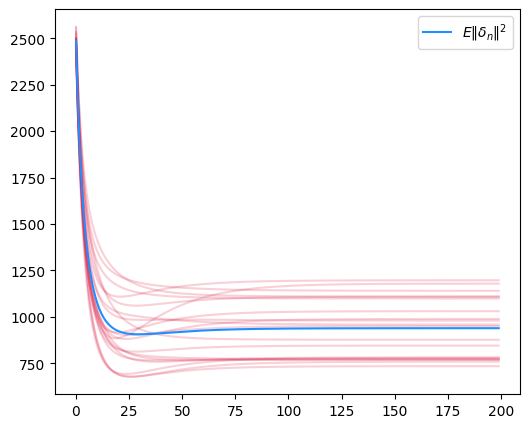

In [30]:
chi2 = np.array(chi2)
trace = np.array(trace)
expec = np.array(expec)

for i in range(pop_size):
    plt.plot(np.array(reconmse_realisations[i])**2, c="crimson", alpha=0.2)

plt.plot([x for x in expec], label="$E \|\delta_n\|^2$", c="dodgerblue")

plt.legend(loc="upper right")
plt.show()

## Decreasing of the MSE

In [11]:
def calc_rhs(n, mu):
    mun = mu**n
    mun_lmu = mun * np.log(mu)
    numerator = mun_lmu[:,None] + mun_lmu[None,:]

    lmbd_outer = np.outer(1-mu, 1-mu)

    log_term = np.zeros(lmbd_outer.shape)
    log_term[lmbd_outer > 0] = np.log(np.outer(mu, mu)[lmbd_outer > 0])
    
    off_diags = np.zeros(lmbd_outer.shape)
    denom = np.outer(mun, mun) * log_term
    off_diags[lmbd_outer > 0] = numerator[lmbd_outer > 0] / denom[lmbd_outer > 0]

    diag = mu ** -n
    off_diags[np.diag_indices_from(off_diags)] = diag

    return off_diags

/tmp/ipykernel_515162/2073109392.py:9: ComplexWarning: Casting complex values to real discards the imaginary part
  log_term[lmbd_outer > 0] = np.log(np.outer(mu, mu)[lmbd_outer > 0])
/tmp/ipykernel_515162/2073109392.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  off_diags[lmbd_outer > 0] = numerator[lmbd_outer > 0] / denom[lmbd_outer > 0]
/tmp/ipykernel_515162/2073109392.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  off_diags[np.diag_indices_from(off_diags)] = diag


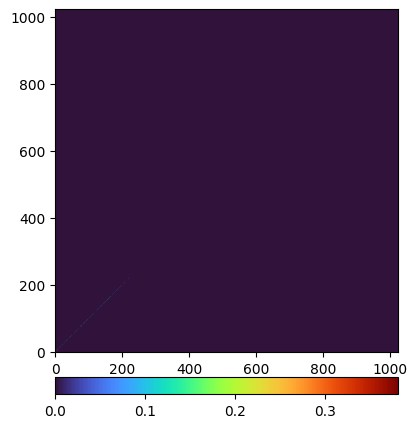

In [45]:
dim = vtrue.shape[0] * vtrue.shape[1]

lmbd_outer = np.outer(lmbd, lmbd)
u_outer_conj = np.outer(u, u.conj())

lhs = np.zeros((dim, dim))
lhs[s > 1e-20] += (r*u_outer_conj*lmbd_outer).real[s > 1e-20]/(sigma2*s*r.T).real[s > 1e-20]
diag = np.ones((dim)) + lmbd**2 * u * u.conj() / (sigma2*np.diag(r))
#lhs[np.diag_indices_from(lhs)] = diag

rhs_n = calc_rhs(1, mu)

#util.plotNImages([(lhs < rhs_n).astype(int)], [""], cmap=cmap)
util.plotNImages([np.abs((r*u_outer_conj*lmbd_outer).real)], [""], cmap=cmap, same_scale=True, scale_mul=0.1)

# print(lmbd_outer.shape)